# Chapter 79 - Tokenizer Libraries After Building One

The previous chapters built a character-initialized BPE-style tokenizer so that tokens, merge order, integer IDs, special tokens, and saved state were visible.

This chapter compares those teaching implementations with a tokenizer-library workflow.

A production tokenizer is not merely a faster copy of the toy tokenizer; it also defines behavior for Unicode, bytes, normalization, serialization, special tokens, and edge cases.

## Learning goals

By the end of this chapter, you will be able to:

- explain why tokenizer libraries exist;
- inspect tokens and IDs from character, homemade subword, and optional library tokenizers;
- compare token counts without treating one tiny example as a quality benchmark;
- distinguish Unicode code points, combining marks, and UTF-8 bytes;
- explain how normalization can change the original string;
- explain how byte-level tokenization provides broad input coverage;
- save and reload a tokenizer mapping reproducibly; and
- explain why token IDs and model parameters are tokenizer-specific.

## The same interface, a larger engineering problem

Every tokenizer in this chapter performs the same broad conversion:

```text
text -> tokens -> token IDs
```

A library implementation adds explicit policies and optimized machinery around that conversion.

Important terms are:

- **Unicode**, the standard that assigns code points to text characters and symbols;
- **byte**, an integer from `0` through `255`;
- **normalization**, a transformation into a chosen standard text form;
- **serialization**, saving tokenizer configuration and learned state; and
- **compatibility**, preserving the exact token-to-ID meaning expected by a trained model.

## The central compatibility warning

Token ID numbers have no universal meaning.

One tokenizer may assign ID `27` to `"cat"`, while another assigns ID `27` to a byte-derived fragment or punctuation mark.

A model's embedding row and output class at index `27` learn the meaning defined by the tokenizer used during training.

Replacing that tokenizer without adapting the model silently changes the input and output meanings even when both tokenizers can encode the same text.

## A shared local corpus

All trainable tokenizers use the same embedded corpus so the comparison does not depend on a network download or external file.

The corpus contains repeated English fragments plus accented text, an emoji, Hebrew, whitespace, and punctuation.

The comparison remains descriptive rather than a benchmark because the algorithms and vocabulary budgets differ.

In [1]:
training_texts = [
    "The cat sat on the mat.",
    "The cat watched the rabbit on the mat.",
    "A Café table had coffee and cake.",
    "Emoji 😊 appears beside ordinary text.",
    "שלום עולם. שלום חבר.",
    "Tabs\tand newlines\nare text too.",
]
training_text = "\n".join(training_texts)
example_text = "The cat sat. Café 😊 שלום"

print("Training characters:", len(training_text))
print("Example text:", repr(example_text))

Training characters: 187
Example text: 'The cat sat. Café 😊 שלום'


The example's characters all occur in the training corpus, so both homemade tokenizers can encode it without an unknown-token fallback.

## Homemade character tokenizer

The character tokenizer assigns deterministic IDs by sorting the observed character vocabulary.

It is exact for known characters but uses one token per Python character.

In [2]:
class HomemadeCharacterTokenizer:
    character_to_id: dict[str, int]
    id_to_character: dict[int, str]
    is_trained: bool

    def __init__(self) -> None:
        self.character_to_id = {}
        self.id_to_character = {}
        self.is_trained = False

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.character_to_id)

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        characters = sorted(set(text))
        self.character_to_id = {
            character: character_id
            for character_id, character in enumerate(characters)
        }
        self.id_to_character = {
            character_id: character
            for character, character_id in self.character_to_id.items()
        }
        self.is_trained = True

    def encode_to_tokens(self, text: str) -> list[str]:
        self._check_trained()
        unknown_characters = sorted(set(text) - set(self.character_to_id))
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")
        return list(text)

    def encode(self, text: str) -> list[int]:
        return [
            self.character_to_id[character]
            for character in self.encode_to_tokens(text)
        ]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        invalid_ids = sorted(set(token_ids) - set(self.id_to_character))
        if invalid_ids:
            raise ValueError(f"Unknown token IDs: {invalid_ids!r}.")
        return "".join(self.id_to_character[token_id] for token_id in token_ids)


character_tokenizer = HomemadeCharacterTokenizer()
character_tokenizer.train(training_text)

character_tokens = character_tokenizer.encode_to_tokens(example_text)
character_token_ids = character_tokenizer.encode(example_text)
character_decoded = character_tokenizer.decode(character_token_ids)

print("Tokens:", character_tokens)
print("Token IDs:", character_token_ids)
print("Token count:", len(character_token_ids))
print("Vocabulary size:", character_tokenizer.vocabulary_size)
print("Decoded:", repr(character_decoded))

assert character_decoded == example_text

Tokens: ['T', 'h', 'e', ' ', 'c', 'a', 't', ' ', 's', 'a', 't', '.', ' ', 'C', 'a', 'f', 'é', ' ', '😊', ' ', 'ש', 'ל', 'ו', 'ם']
Token IDs: [7, 14, 12, 2, 10, 8, 25, 2, 24, 8, 25, 3, 2, 5, 8, 13, 29, 2, 38, 2, 37, 33, 31, 34]
Token count: 24
Vocabulary size: 39
Decoded: 'The cat sat. Café 😊 שלום'


The token list is easy to inspect, but the sequence is as long as the string's Python-character count.

## Homemade subword tokenizer

The compact implementation below preserves the Chapter 76 and 77 invariants: lexical tie-breaking, ordered non-overlapping merges, and a cumulative vocabulary.

It remains a teaching implementation with straightforward Python scans rather than a production tokenizer.

In [3]:
from collections import Counter
from dataclasses import dataclass

TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    index: int
    pair: TokenPair
    new_token: str


def count_adjacent_token_pairs(
    token_sequence: list[str],
) -> Counter[TokenPair]:
    return Counter(zip(token_sequence, token_sequence[1:], strict=False))


def select_most_frequent_pair(
    pair_counts: Counter[TokenPair],
) -> TokenPair:
    highest_count = max(pair_counts.values())
    tied_pairs = [
        pair
        for pair, count in pair_counts.items()
        if count == highest_count
    ]
    return min(tied_pairs)


def merge_pair_in_sequence(
    token_sequence: list[str],
    pair_to_merge: TokenPair,
    merged_token: str,
) -> list[str]:
    merged_sequence: list[str] = []
    position = 0

    while position < len(token_sequence):
        pair_matches = (
            position + 1 < len(token_sequence)
            and token_sequence[position] == pair_to_merge[0]
            and token_sequence[position + 1] == pair_to_merge[1]
        )

        if pair_matches:
            merged_sequence.append(merged_token)
            position += 2
        else:
            merged_sequence.append(token_sequence[position])
            position += 1

    return merged_sequence


class HomemadeSubwordTokenizer:
    number_of_merges: int
    merge_rules: list[MergeRule]
    base_alphabet: set[str]
    subword_to_id: dict[str, int]
    id_to_subword: dict[int, str]
    is_trained: bool

    def __init__(self, number_of_merges: int) -> None:
        if number_of_merges < 0:
            raise ValueError("number_of_merges must be nonnegative.")

        self.number_of_merges = number_of_merges
        self.merge_rules = []
        self.base_alphabet = set()
        self.subword_to_id = {}
        self.id_to_subword = {}
        self.is_trained = False

    @property
    def vocabulary_size(self) -> int:
        self._check_trained()
        return len(self.subword_to_id)

    def _check_trained(self) -> None:
        if not self.is_trained:
            raise RuntimeError("Tokenizer must be trained before use.")

    def train(self, text: str) -> None:
        if not text:
            raise ValueError("Training text must not be empty.")

        token_sequence = list(text)
        base_alphabet = set(token_sequence)
        vocabulary = set(base_alphabet)
        merge_rules: list[MergeRule] = []

        for merge_index in range(self.number_of_merges):
            pair_counts = count_adjacent_token_pairs(token_sequence)
            if not pair_counts:
                break

            pair_to_merge = select_most_frequent_pair(pair_counts)
            new_token = "".join(pair_to_merge)
            if new_token in vocabulary:
                raise RuntimeError(f"Merge token collision for {new_token!r}.")

            token_sequence = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=pair_to_merge,
                merged_token=new_token,
            )
            merge_rules.append(
                MergeRule(
                    index=merge_index,
                    pair=pair_to_merge,
                    new_token=new_token,
                )
            )
            vocabulary.add(new_token)

        sorted_vocabulary = sorted(vocabulary)
        self.merge_rules = merge_rules
        self.base_alphabet = base_alphabet
        self.subword_to_id = {
            subword: token_id
            for token_id, subword in enumerate(sorted_vocabulary)
        }
        self.id_to_subword = {
            token_id: subword
            for subword, token_id in self.subword_to_id.items()
        }
        self.is_trained = True

    def encode_to_tokens(self, text: str) -> list[str]:
        self._check_trained()
        unknown_characters = sorted(set(text) - self.base_alphabet)
        if unknown_characters:
            raise ValueError(f"Unknown characters: {unknown_characters!r}.")

        token_sequence = list(text)
        for merge_rule in self.merge_rules:
            token_sequence = merge_pair_in_sequence(
                token_sequence=token_sequence,
                pair_to_merge=merge_rule.pair,
                merged_token=merge_rule.new_token,
            )
        return token_sequence

    def encode(self, text: str) -> list[int]:
        return [
            self.subword_to_id[token]
            for token in self.encode_to_tokens(text)
        ]

    def decode(self, token_ids: list[int]) -> str:
        self._check_trained()
        invalid_ids = sorted(set(token_ids) - set(self.id_to_subword))
        if invalid_ids:
            raise ValueError(f"Unknown token IDs: {invalid_ids!r}.")
        return "".join(self.id_to_subword[token_id] for token_id in token_ids)


subword_tokenizer = HomemadeSubwordTokenizer(number_of_merges=40)
subword_tokenizer.train(training_text)

subword_tokens = subword_tokenizer.encode_to_tokens(example_text)
subword_token_ids = subword_tokenizer.encode(example_text)
subword_decoded = subword_tokenizer.decode(subword_token_ids)

print("Tokens:", subword_tokens)
print("Token IDs:", subword_token_ids)
print("Token count:", len(subword_token_ids))
print("Vocabulary size:", subword_tokenizer.vocabulary_size)
print("Decoded:", repr(subword_decoded))

assert subword_decoded == example_text
assert len(subword_token_ids) < len(character_token_ids)

Tokens: ['The cat ', 's', 'at', '.', ' ', 'C', 'a', 'f', 'é', ' ', '😊', ' ', 'ש', 'ל', 'ום']
Token IDs: [28, 60, 34, 20, 14, 23, 29, 45, 65, 14, 78, 14, 76, 71, 68]
Token count: 15
Vocabulary size: 79
Decoded: 'The cat sat. Café 😊 שלום'


Repeated pieces reduce this in-domain example's sequence length, but the tokenizer still lacks robust fallback, normalization policy, optimized training, and a standard serialized format.

## Optional library tokenizer

The project does not require the third-party `tokenizers` package, so this section detects it without installing or downloading anything.

When available, the code trains a local byte-level BPE tokenizer using the official in-memory training API.

`ByteLevel.alphabet()` supplies all 256 byte-derived alphabet symbols, and the matching decoder reconstructs readable text.

See the official [training-from-memory documentation](https://huggingface.co/docs/tokenizers/training_from_memory) and [component reference](https://huggingface.co/docs/tokenizers/main/components) for the library pipeline used here.

In [4]:
from typing import Any

TOKENIZERS_LIBRARY_AVAILABLE = False
library_tokenizer: Any | None = None
library_tokens: list[str] | None = None
library_token_ids: list[int] | None = None
library_decoded: str | None = None
library_vocabulary_size: int | None = None

try:
    from tokenizers import Tokenizer  # type: ignore[import-not-found]
    from tokenizers.decoders import (  # type: ignore[import-not-found]
        ByteLevel as ByteLevelDecoder,
    )
    from tokenizers.models import BPE  # type: ignore[import-not-found]
    from tokenizers.pre_tokenizers import (  # type: ignore[import-not-found]
        ByteLevel,
    )
    from tokenizers.trainers import BpeTrainer  # type: ignore[import-not-found]

    TOKENIZERS_LIBRARY_AVAILABLE = True
except ImportError:
    pass


if TOKENIZERS_LIBRARY_AVAILABLE:
    library_tokenizer = Tokenizer(BPE(unk_token="<unknown>"))
    library_tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
    library_tokenizer.decoder = ByteLevelDecoder()

    library_trainer = BpeTrainer(
        vocab_size=300,
        min_frequency=2,
        show_progress=False,
        special_tokens=["<unknown>"],
        initial_alphabet=ByteLevel.alphabet(),
    )
    library_tokenizer.train_from_iterator(
        training_texts,
        trainer=library_trainer,
    )

    library_encoding = library_tokenizer.encode(example_text)
    library_tokens = library_encoding.tokens
    library_token_ids = library_encoding.ids
    library_decoded = library_tokenizer.decode(library_token_ids)
    library_vocabulary_size = library_tokenizer.get_vocab_size()

    assert library_token_ids is not None
    print("Tokens:", library_tokens)
    print("Token IDs:", library_token_ids)
    print("Token count:", len(library_token_ids))
    print("Vocabulary size:", library_vocabulary_size)
    print("Decoded:", repr(library_decoded))
    assert library_decoded == example_text
else:
    print("Optional dependency 'tokenizers' is not installed.")
    print("The local library-tokenizer example is skipped.")

Optional dependency 'tokenizers' is not installed.
The local library-tokenizer example is skipped.


Byte-level token strings can look unusual because visible Unicode symbols stand in for bytes and spaces.

Readable token display is less important than stable IDs, full input coverage, and correct decoding.

In this executed notebook the optional dependency may be unavailable, but the remaining comparisons continue without changing the locked environment.

## Compare tokens, IDs, and counts

The next cell prints each available representation together.

The numeric IDs are intentionally not aligned because every tokenizer owns a different vocabulary mapping.

In [5]:
print("=" * 72)
print("Homemade characters")
print("tokens:", character_tokens)
print("ids:", character_token_ids)
print("count:", len(character_token_ids))
print()
print("=" * 72)
print("Homemade subwords")
print("tokens:", subword_tokens)
print("ids:", subword_token_ids)
print("count:", len(subword_token_ids))

if TOKENIZERS_LIBRARY_AVAILABLE:
    print()
    print("=" * 72)
    print("Library byte-level BPE")
    print("tokens:", library_tokens)
    print("ids:", library_token_ids)
    print("count:", len(library_token_ids or []))

Homemade characters
tokens: ['T', 'h', 'e', ' ', 'c', 'a', 't', ' ', 's', 'a', 't', '.', ' ', 'C', 'a', 'f', 'é', ' ', '😊', ' ', 'ש', 'ל', 'ו', 'ם']
ids: [7, 14, 12, 2, 10, 8, 25, 2, 24, 8, 25, 3, 2, 5, 8, 13, 29, 2, 38, 2, 37, 33, 31, 34]
count: 24

Homemade subwords
tokens: ['The cat ', 's', 'at', '.', ' ', 'C', 'a', 'f', 'é', ' ', '😊', ' ', 'ש', 'ל', 'ום']
ids: [28, 60, 34, 20, 14, 23, 29, 45, 65, 14, 78, 14, 76, 71, 68]
count: 15


The same text becomes different token strings, ID sequences, and sequence lengths.

Those differences affect context usage and computation, but token count alone does not measure tokenizer or model quality.

The chart records sequence length for this one example.

It is not a speed, compression, multilingual quality, or downstream-model benchmark.

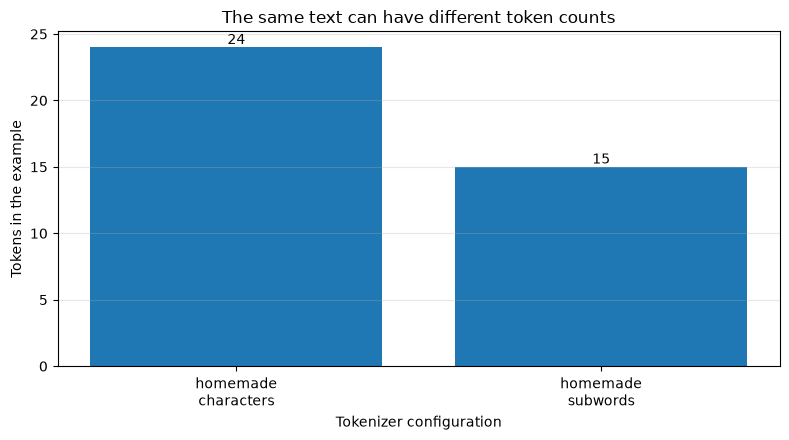

In [6]:
import matplotlib.pyplot as plt

token_counts = {
    "homemade\ncharacters": len(character_token_ids),
    "homemade\nsubwords": len(subword_token_ids),
}
if TOKENIZERS_LIBRARY_AVAILABLE and library_token_ids is not None:
    token_counts["library\nbyte BPE"] = len(library_token_ids)

figure, axis = plt.subplots(figsize=(8, 4.5))
bars = axis.bar(list(token_counts), list(token_counts.values()))
axis.bar_label(bars)
axis.set_xlabel("Tokenizer configuration")
axis.set_ylabel("Tokens in the example")
axis.set_title("The same text can have different token counts")
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()

The homemade subword tokenizer uses fewer positions than the character tokenizer on this repeated in-domain text.

If the optional library bar is absent, that means the package was unavailable rather than that its count was zero.

## Unicode code points are not visual characters

Python strings are sequences of Unicode code points.

Two strings can look alike while using different code-point sequences, such as precomposed `é` and `e` followed by a combining acute accent.

The next inspection prints `repr()` and code-point names so the difference is visible.

In [7]:
import unicodedata

unicode_examples = [
    "Café",
    "Cafe\u0301",
    "😊",
    "שלום",
]

for unicode_text in unicode_examples:
    code_point_descriptions = [
        f"U+{ord(character):04X} {unicodedata.name(character, 'UNNAMED')}"
        for character in unicode_text
    ]
    print("text:", repr(unicode_text))
    print("Python characters:", list(unicode_text))
    print("code points:", code_point_descriptions)
    print("length:", len(unicode_text))
    print("-" * 72)

text: 'Café'
Python characters: ['C', 'a', 'f', 'é']
code points: ['U+0043 LATIN CAPITAL LETTER C', 'U+0061 LATIN SMALL LETTER A', 'U+0066 LATIN SMALL LETTER F', 'U+00E9 LATIN SMALL LETTER E WITH ACUTE']
length: 4
------------------------------------------------------------------------
text: 'Café'
Python characters: ['C', 'a', 'f', 'e', '́']
code points: ['U+0043 LATIN CAPITAL LETTER C', 'U+0061 LATIN SMALL LETTER A', 'U+0066 LATIN SMALL LETTER F', 'U+0065 LATIN SMALL LETTER E', 'U+0301 COMBINING ACUTE ACCENT']
length: 5
------------------------------------------------------------------------
text: '😊'
Python characters: ['😊']
code points: ['U+1F60A SMILING FACE WITH SMILING EYES']
length: 1
------------------------------------------------------------------------
text: 'שלום'
Python characters: ['ש', 'ל', 'ו', 'ם']
code points: ['U+05E9 HEBREW LETTER SHIN', 'U+05DC HEBREW LETTER LAMED', 'U+05D5 HEBREW LETTER VAV', 'U+05DD HEBREW LETTER FINAL MEM']
length: 4
--------------------------

The two café spellings have different lengths and code points even though many fonts render them similarly.

A tokenizer needs an explicit normalization policy rather than assuming visual similarity implies string equality.

## Normalization changes the tokenizer's input

Unicode normalization form NFC composes compatible sequences when a composed representation exists.

That can make the two café spellings equal after normalization, but the normalized string is not byte-for-byte identical to every original input.

In [8]:
composed_text = "Café"
decomposed_text = "Cafe\u0301"

normalized_composed = unicodedata.normalize("NFC", composed_text)
normalized_decomposed = unicodedata.normalize("NFC", decomposed_text)

print("Equal before normalization:", composed_text == decomposed_text)
print("Equal after NFC normalization:", normalized_composed == normalized_decomposed)
print("Decomposed input:", list(decomposed_text))
print("Normalized output:", list(normalized_decomposed))

assert composed_text != decomposed_text
assert normalized_composed == normalized_decomposed

Equal before normalization: False
Equal after NFC normalization: True
Decomposed input: ['C', 'a', 'f', 'e', '́']
Normalized output: ['C', 'a', 'f', 'é']


Normalization can be appropriate, but it changes what exact round-trip correctness means.

If a tokenizer normalizes first, decoding may reconstruct the normalized text rather than the original code-point sequence.

Lowercasing or whitespace cleanup can discard even more visible information.

## UTF-8 bytes provide a finite base alphabet

UTF-8 converts Unicode text to bytes.

One Python character may require several bytes, while every byte is still one of only 256 possible values.

In [9]:
byte_examples = ["A", "é", "😊", "שלום"]

for byte_text in byte_examples:
    utf8_bytes = byte_text.encode("utf-8")
    print("text:", repr(byte_text))
    print("Python characters:", len(byte_text))
    print("UTF-8 bytes:", list(utf8_bytes))
    print("byte count:", len(utf8_bytes))
    print("round trip:", utf8_bytes.decode("utf-8") == byte_text)
    print("-" * 48)

text: 'A'
Python characters: 1
UTF-8 bytes: [65]
byte count: 1
round trip: True
------------------------------------------------
text: 'é'
Python characters: 1
UTF-8 bytes: [195, 169]
byte count: 2
round trip: True
------------------------------------------------
text: '😊'
Python characters: 1
UTF-8 bytes: [240, 159, 152, 138]
byte count: 4
round trip: True
------------------------------------------------
text: 'שלום'
Python characters: 4
UTF-8 bytes: [215, 169, 215, 156, 215, 149, 215, 157]
byte count: 8
round trip: True
------------------------------------------------


A byte-level tokenizer can begin from a fixed byte alphabet and therefore represent arbitrary valid UTF-8 text without adding every Unicode code point to its base vocabulary.

The tradeoff is that some visible characters initially span several byte tokens, and the displayed byte-derived token strings may be unfamiliar.

## Saved tokenizer state matters

A learned tokenizer includes its vocabulary, merge rules, special-token configuration, normalization, pre-tokenizer, and decoder policies.

Retraining from similar data is not a substitute for preserving the exact mapping because settings, corpus order, tie-breaking, or library versions can change IDs.

When the optional library is available, the following cell serializes to a temporary directory, reloads the JSON, and verifies identical IDs without leaving an artifact in the repository.

In [10]:
from pathlib import Path
from tempfile import TemporaryDirectory

if TOKENIZERS_LIBRARY_AVAILABLE and library_tokenizer is not None:
    with TemporaryDirectory() as temporary_directory:
        tokenizer_path = Path(temporary_directory) / "tokenizer.json"
        library_tokenizer.save(str(tokenizer_path))
        loaded_library_tokenizer = Tokenizer.from_file(str(tokenizer_path))

        original_ids = library_tokenizer.encode(example_text).ids
        loaded_ids = loaded_library_tokenizer.encode(example_text).ids

        print("Temporary tokenizer file existed:", tokenizer_path.exists())
        print("Original IDs:", original_ids)
        print("Loaded IDs:", loaded_ids)
        print("IDs match:", original_ids == loaded_ids)
        assert original_ids == loaded_ids
else:
    print("Save/load example skipped because 'tokenizers' is unavailable.")

Save/load example skipped because 'tokenizers' is unavailable.


The temporary file is removed automatically after the check.

In a real model release, the serialized tokenizer belongs beside the model checkpoint or under a stable referenced version.

## The same ID can mean different tokens

The table below compares the homemade mappings at shared numeric indices.

It demonstrates the incompatibility directly rather than comparing vocabulary sizes alone.

In [11]:
shared_id_limit = min(
    character_tokenizer.vocabulary_size,
    subword_tokenizer.vocabulary_size,
)
mapping_differences = [
    (
        token_id,
        character_tokenizer.id_to_character[token_id],
        subword_tokenizer.id_to_subword[token_id],
    )
    for token_id in range(shared_id_limit)
    if (
        character_tokenizer.id_to_character[token_id]
        != subword_tokenizer.id_to_subword[token_id]
    )
]

print("token ID | character token | subword token")
print("-" * 52)
for token_id, character_token, subword_token in mapping_differences[:10]:
    print(f"{token_id:>8} | {character_token!r:>15} | {subword_token!r}")

assert mapping_differences

token ID | character token | subword token
----------------------------------------------------
       1 |            '\n' | '\tand '
       2 |             ' ' | '\tand n'
       3 |             '.' | '\tand ne'
       4 |             'A' | '\tand new'
       5 |             'C' | '\tand newl'
       6 |             'E' | '\tand newlin'
       7 |             'T' | '\tand newlines'
       8 |             'a' | '\tand newlines\n'
       9 |             'b' | '\tand newlines\nar'
      10 |             'c' | '\tand newlines\nare '


Matching integer ranges do not imply matching semantics.

A model trained with the character mapping cannot interpret the subword IDs merely because both are Python integers within bounds.

## Libraries solve more than coverage

Robust tokenizer packages commonly provide:

- optimized compiled implementations and efficient data structures;
- configurable normalizers, pre-tokenizers, models, post-processors, and decoders;
- stable serialization of vocabulary and pipeline configuration;
- alignment information between source text and token spans;
- deliberate handling of special tokens and byte fallback; and
- well-tested behavior across large corpora and edge cases.

Our Python loops are useful because they expose the mechanism, not because they should process a production-scale corpus.

## Round-trip checks have a precise scope

Both homemade tokenizers reconstruct the known example exactly.

The optional byte-level configuration is also required to reconstruct it when available.

In [12]:
round_trip_results = {
    "homemade characters": character_decoded == example_text,
    "homemade subwords": subword_decoded == example_text,
}
if TOKENIZERS_LIBRARY_AVAILABLE:
    round_trip_results["library byte BPE"] = library_decoded == example_text

for tokenizer_name, round_trip_passed in round_trip_results.items():
    print(f"{tokenizer_name:<24}: {round_trip_passed}")
    assert round_trip_passed

homemade characters     : True
homemade subwords       : True


An exact round trip confirms information preservation under the configured pipeline.

It does not prove that segmentation is efficient, that training data is representative, or that a downstream language model will be good.

## Common mistakes

- Do not treat token IDs as interchangeable across tokenizers.
- Do not compare token counts as if they alone measured tokenizer quality.
- Do not assume visually identical strings have identical code points or bytes.
- Do not normalize without defining what information may change.
- Do not infer an unavailable optional library has zero tokens from an omitted plot bar.
- Do not save generated tokenizer artifacts into the repository during a teaching run.
- Do not retrain a tokenizer when a model requires an exact saved mapping.
- Do not assume a successful round trip makes a toy tokenizer production-ready.

## Takeaways

Building a tokenizer first makes the responsibilities of a library pipeline visible.

The broad conversion is still `text -> tokens -> token IDs`, but production tooling adds byte coverage, normalization policies, speed, serialization, alignment, and tested edge-case behavior.

The same text can produce different tokens, counts, and IDs under different configurations.

Those IDs are part of the trained model's meaning, so a model checkpoint must retain or reference its exact tokenizer.

## What comes next

The next chapter can choose one tokenizer state, encode a corpus, and build shifted GPT input-target batches from those fixed token IDs.

That transition will use the tokenizer's exact vocabulary size and will preserve the tokenizer beside any resulting model checkpoint.